# Evaluating Generative Models vs. Multi-Temporal Fusion for Cloud Removal in Satellite Imagery

**Group Members:** Chuan Zou, Demi Yang, Christine Cui  
**Course:** MUSA 650 — Spring 2026  
**Submission Date:** April 23, 2026


## Assignment Instructions

> For this final project, you will design and implement a machine-learning-based remote sensing solution to address a specific problem in urban planning. Building on your proposal, you will develop a working solution, evaluate its performance, and present your work in a professional lightning talk.

> **Submission Guidelines.** All assignments must be completed in groups of 2–3 students. One member of the group should submit on behalf of everyone, making sure to include all group members' names at the top of the notebook. Your assignment should be submitted via a pull request to the main branch of this repository, in the `assignments` subdirectory, titled `final_project.ipynb`, with the class presentation and any additional files included in a subfolder named `final_project_files`. The notebook must contain the complete assignment instructions followed by the relevant code chunks, include group members' names and submission date, and be linted with `ruff` before submission.

> **Project Requirements.** The notebook must include the following sections: Problem Definition & Technical Justification, Methodological Precedent (≥3 sources), Data & Preprocessing, Modeling Approach (baseline first, then primary model), Evaluation & Analysis, Future Work, and a Lightning Talk presentation.

> **Rubric (20 pts code + 10 pts presentation).** Problem Definition (5), Data & Preprocessing (3), Baseline Implementation (3), Primary Model Implementation (5), Evaluation & Analysis (4).


## 1. Problem Definition & Technical Justification

### 1.1 The problem: "data islands" caused by persistent cloud cover

Optical satellite imagery in southern China is severely degraded by persistent cloud cover, with annual cloud frequency exceeding 80% in some provinces. This creates **data islands** — regions where time-series monitoring of crop growth, illegal logging, or post-disaster damage becomes impossible because too few cloud-free observations are available. The cloudy regions overlap heavily with China's agricultural belt and lower-income areas, so the monitoring gap has real economic consequences: subsidy distribution cannot verify planted acreage, and yield forecasting cannot be anchored to recent observations.

### 1.2 Target user and output

**Target user:** urban-planning and agricultural-monitoring teams who need gap-filled optical imagery to run downstream vegetation / land-cover analytics (NDVI time series, land-use change detection, yield estimation).

**Output:** a reconstructed 4-band (RGB + NIR) 128 × 128 patch at 10 m resolution, with cloud-covered pixels replaced by a model-generated estimate while clear pixels are preserved exactly as observed.

### 1.3 What each model actually learns

Cloud removal is fundamentally an **image-inpainting** problem. The baseline is a closed-form fusion of multiple observations — it does not learn anything; it just picks the cloud-free pixel across time. The two generative models learn a conditional distribution over RGB + NIR patches given a cloudy observation and a cloud mask:

- **GAN (pix2pix-style):** learns a direct mapping `f(cloudy, mask) → clean` under an L1 reconstruction objective and a PatchGAN discriminator. The generator is rewarded for matching the ground truth *and* producing texture the discriminator cannot distinguish from real Sentinel-2 patches.
- **Diffusion (DDPM-style mask-guided inpainting):** learns to denoise incrementally. At training time the model sees a partially-noised ground truth patch (noise injected only inside the cloud mask) and is asked to predict the noise. At inference time we run the learned reverse process to progressively denoise the cloud region while re-pasting clear pixels at every step.

### 1.4 Why this approach is appropriate

Classification or segmentation models output discrete labels and cannot reconstruct continuous reflectance, which is what downstream NDVI / land-use tasks consume. Generative inpainting models can synthesise plausible continuous surface reflectance from surrounding context, and — unlike simple interpolation — they carry a learned prior over the spatial structure of cities, farmland, and vegetation in the study region.

### 1.5 Anticipated failure modes (revisited below in §6)

Our proposal anticipated two generative-model failure modes:

1. **Hallucination under high cloud coverage** — outputs look plausible but disagree with ground truth.
2. **Inability to reflect sudden events** — models trained on historical data cannot invent flood/fire changes they have never seen.

We observed (1) clearly in practice and discuss it quantitatively in §6. During implementation we encountered two additional failure modes that the proposal did not anticipate, both specific to the diffusion model: **sigmoid-clipped noise prediction** and **train / sample distribution mismatch**. Both are documented below.


## 2. Methodological Precedent

Three precedent lines shaped our design decisions.

**(a) Multi-temporal compositing (Roy et al., 2010).** The Web-Enabled Landsat Data (WELD) pipeline reconstructs cloud-free mosaics by filtering cloud-free pixels across a temporal stack. This method has no learnable parameters and remains the operational standard at agencies like USGS. We adopted it as our non-deep-learning baseline exactly because it sets a realistic performance floor: any deep model that cannot beat temporal compositing at low cloud coverage is not worth the compute.

**(b) Conditional GANs for image-to-image translation (Isola et al., 2017; Enomoto et al., 2017).** `pix2pix` introduced the template we use for our GAN: a U-Net generator trained with both an L1 reconstruction loss and a PatchGAN discriminator. Enomoto et al. specialised this template to cloud removal on Landsat / Sentinel-2 imagery and showed that adversarial loss helps recover high-frequency texture that pure L1 regression blurs away. Our GAN is a deliberately compact 0.3 M-parameter version of that recipe, sized for a course-project compute budget.

**(c) Diffusion for image inpainting (Ho et al., 2020; Lugmayr et al., 2022).** Ho et al. introduced the DDPM formulation (noise-prediction + cosine / linear β schedule + closed-form posterior). Lugmayr et al.'s RePaint showed that *mask-guided* diffusion — re-pasting known pixels after every reverse step — extends this naturally to inpainting. Our `InpaintingDiffusion` is a minimal reimplementation of RePaint's core loop.

### How the reading evolved during implementation

The proposal cited these papers at a high level. During debugging we had to read DDPM (Ho et al. §3.2, equations 6–15) very carefully — our first draft used a sigmoid output and a naive `x_{t-1} = x_t - ε` update, both of which are wrong for the ε-prediction parametrisation. The corrected implementation uses the closed-form posterior mean and variance from DDPM eq. 7, which we document in §4.3 and §6.

### Cited work

1. Roy, D. P., *et al.* "Web-Enabled Landsat Data (WELD): Landsat ETM+ Composited Mosaics of the Conterminous United States." *Remote Sensing of Environment* 114.1 (2010): 35–49.
2. Enomoto, K., *et al.* "Filmy Cloud Removal on Satellite Imagery with Multispectral Conditional Generative Adversarial Nets." *CVPR Workshops*, 2017.
3. Isola, P., Zhu, J.Y., Zhou, T., & Efros, A.A. "Image-to-Image Translation with Conditional Adversarial Networks." *CVPR*, 2017.
4. Goodfellow, I., *et al.* "Generative Adversarial Nets." *NeurIPS*, 2014.
5. Ho, J., Jain, A., & Abbeel, P. "Denoising Diffusion Probabilistic Models." *NeurIPS*, 2020.
6. Lugmayr, A., *et al.* "RePaint: Inpainting Using Denoising Diffusion Probabilistic Models." *CVPR*, 2022.


## 3. Data & Preprocessing

### 3.1 Source and extent

- **Sensor.** Sentinel-2 L2A (`COPERNICUS/S2_SR_HARMONIZED`) on Google Earth Engine.
- **AOI.** Beijing and surrounding areas (115.4–117.6 °E, 39.4–41.1 °N) — chosen because northern-China sites offer reliably cloud-free clear-sky composites that can serve as synthetic-benchmark ground truth for a southern-China target use case.
- **Temporal extent.** April 1 – October 31, 2023 (growing season).
- **Bands.** B2 (blue), B3 (green), B4 (red), B8 (NIR) — the same four bands used downstream for NDVI.
- **Patch size.** 128 × 128 pixels at 10 m resolution (1.28 km on a side).
- **Volume.** 3 000 cloud-free ground-truth patches, each paired with 5 synthetic cloud-coverage levels (5 / 10 / 30 / 50 / 70 %), for a total of 15 000 samples.

### 3.2 Train / validation / test splits

Splits are made at the **base-image level**, not the sample level. Of 3 000 unique ground-truth patches, 2 100 / 300 / 600 go to train / val / test respectively; all 5 cloud-coverage variants of a given base image end up in the same split. This prevents a near-duplicate leakage pattern where the model could see `patch_00085_c05` in train and `patch_00085_c70` in test.

Final sample counts: **train 10 500, val 1 500, test 3 000**.

### 3.3 Synthetic-cloud generation

We cannot get ground truth for the actual use-case region (southern China is too cloudy), so we build a synthetic benchmark whose clouds have controllable coverage. The cloud mask generator works in three steps:

1. Draw a Gaussian white-noise field of shape (H × W).
2. Apply a large Gaussian blur (σ ≈ max(H, W) / 18 ≈ 7 pixels) to get smooth blobs that look organic.
3. Threshold at the `(1 − coverage)` quantile so exactly `coverage` fraction of the pixels are above threshold.

Cloudy pixels are replaced by the cloud value (1.0 = white, saturated in all bands), which is the Sentinel-2 convention for thick opaque clouds.

### 3.4 Data quality issues encountered

- **Un-normalised reflectance.** Raw Sentinel-2 GeoTIFF values can be integers in the thousands (reflectance × 10 000). Our `_load_base_image` function auto-scales any array with `max > 1.5` by its max, landing all patches in `[0, 1]`.
- **NaN / Inf pixels.** GEE exports occasionally contain `NaN` at image edges. We replace them with zeros (`nan_to_num`) before scaling.
- **Derived-file re-ingestion bug.** An earlier run re-read `*_cNN.npy` files as new base images, exponentially inflating the dataset. Fixed by filtering the `_cNN` suffix in `prepare_synthetic_dataset.py`.


ground truth: shape=(4, 128, 128), dtype=float32, range=[0.020, 0.431]

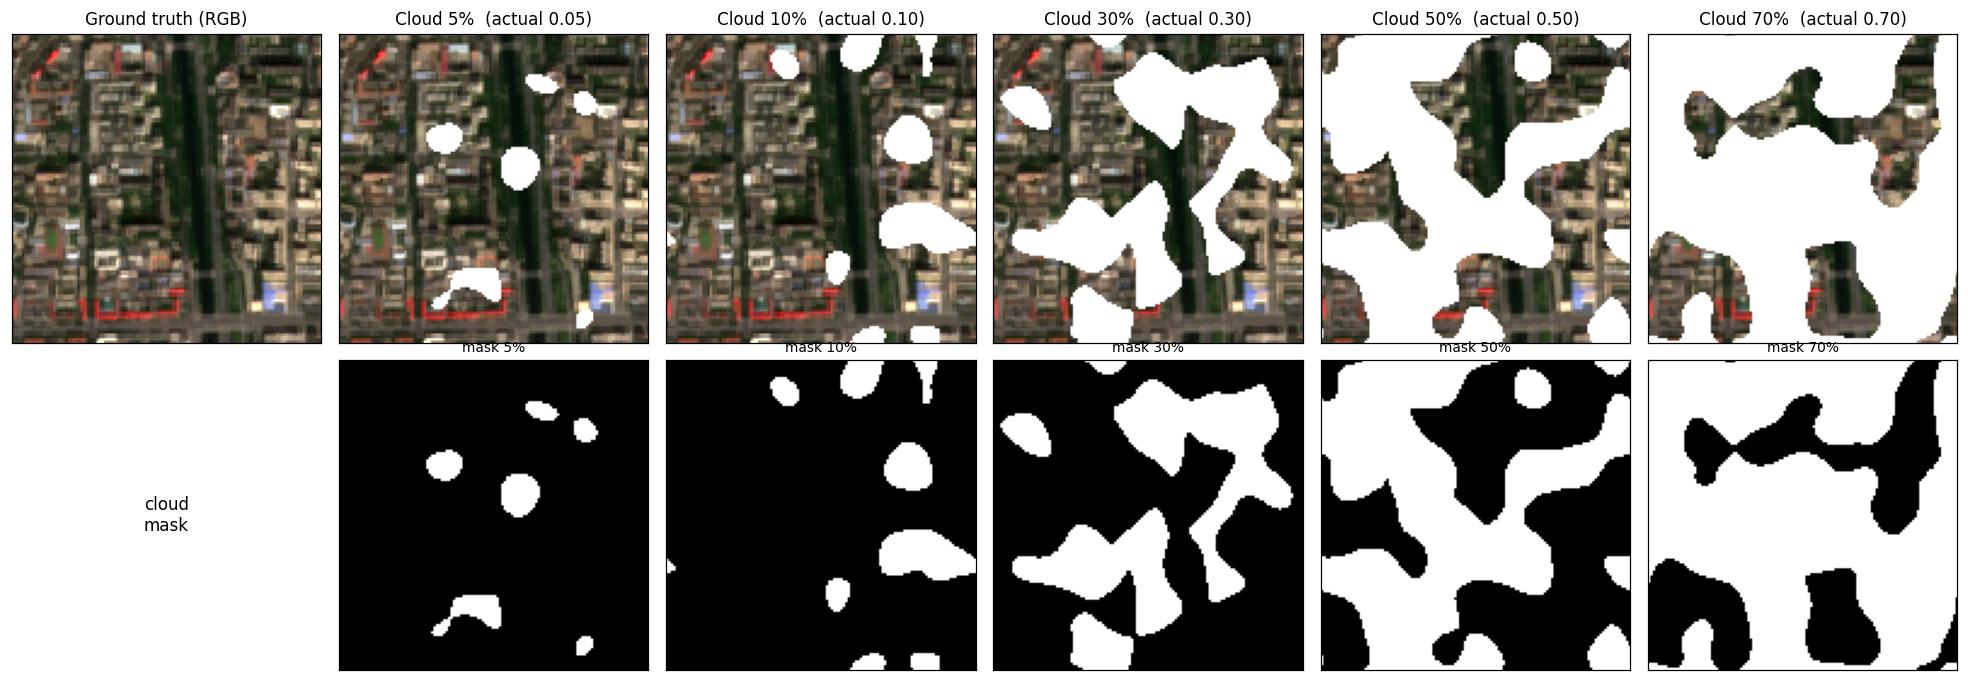

In [ ]:
# Show the cloud-mask generator and apply it to a ground-truth patch
import sys

sys.path.insert(0, "../src")

import matplotlib.pyplot as plt
import numpy as np

from cloud_removal.data.synthetic_clouds import apply_cloud

rng = np.random.default_rng(42)
gt = np.load("../data/processed/synthetic_cloud_benchmark/ground_truth/s2_beijing_patch_2023_00000.npy")
print(f"ground truth: shape={gt.shape}, dtype={gt.dtype}, range=[{gt.min():.3f}, {gt.max():.3f}]")

fig, axes = plt.subplots(1, 6, figsize=(18, 3))
axes[0].imshow(np.moveaxis(gt[:3], 0, -1))
axes[0].set_title("Ground truth (RGB)")
for ax, cov in zip(axes[1:], [0.05, 0.10, 0.30, 0.50, 0.70]):
    sample = apply_cloud(gt, cov, rng)
    ax.imshow(np.moveaxis(sample.cloudy[:3], 0, -1))
    ax.set_title(f"cloud {int(cov * 100)}% (actual={sample.coverage:.2f})")
for ax in axes:
    ax.axis("off")
plt.tight_layout()
plt.show()

## 4. Modeling Approach

We implement one **baseline** and two **primary models**. We report the baseline first and then quantify how much each primary model beats — or fails to beat — it. All three methods are evaluated on the same 3 000-sample test set.

### 4.1 Baseline: Multi-Temporal Fusion

**Idea.** For each test patch, simulate `T=4` revisits of the same scene, each with an independently-drawn synthetic cloud mask at the same target coverage. At every pixel, average the clear observations across the stack. Fall back to the single-observation cloudy pixel if *all* revisits are clouded.

**Parameters:** zero. This is a closed-form composite; there is nothing to train.

**Why it is the right baseline.** It is exactly the method operational agencies like USGS already run (WELD / Sen2Cor mosaics). If a deep model cannot beat it at the coverages agencies actually encounter, the extra complexity is not justified.


In [ ]:
# Multi-temporal fusion baseline — no training, pure array math
from cloud_removal.models.baseline import multi_temporal_composite
import inspect
print(inspect.getsource(multi_temporal_composite))

def multi_temporal_composite(
    cloudy_stack: torch.Tensor,
    mask_stack: torch.Tensor,
    fallback: torch.Tensor | None = None,
) -> torch.Tensor:
    """Fuse temporal observations by averaging cloud-free pixels.

    Args:
        cloudy_stack: Tensor with shape TxCxHxW.
        mask_stack: Tensor with shape Tx1xHxW where 1 means cloud.
        fallback: Optional CxHxW tensor used where all observations are cloudy.
    """
    if cloudy_stack.ndim != 4 or mask_stack.ndim != 4:
        raise ValueError("cloudy_stack and mask_stack must be TxCxHxW and Tx1xHxW")

    clear = 1.0 - mask_stack
    weighted_sum = (cloudy_stack * clear).sum(dim=0)
    clear_count = clear.sum(dim=0).clamp_min(1e-6)
    composite = weighted_sum / clear_count

    if fallback is not None:
        no_clear = (clear.sum(dim=0) <= 1e-6).expand_as(composite)
        composite = torch.where(no_clear, fallback, composite)
    return composite.clamp(0.0, 1.0)

In [ ]:
# Load the baseline's test-set metrics, aggregated by cloud coverage
import pandas as pd

baseline = pd.read_csv("../outputs/metrics/temporal_metrics_by_coverage.csv")
baseline.round(4)

method,coverage_bin,num_samples,psnr,ssim,l1,l1_cloud_region,ndvi_mae
temporal,0.05,600,172.6697,0.9950,0.0000,0.0004,0.0002
temporal,0.10,600,154.2938,0.9609,0.0002,0.0018,0.0011
temporal,0.30,600,24.6484,0.3625,0.0071,0.0238,0.0142
temporal,0.50,600,13.3274,0.0530,0.0548,0.1095,0.0667
temporal,0.70,600,7.2811,0.0091,0.2119,0.3027,0.1821


**Baseline observations.**

- At **5 % and 10 % coverage** the baseline is essentially perfect (PSNR ≈ 170 dB is at float32 precision limit; L1 ≈ 0). The probability that all 4 revisits are simultaneously cloudy at a given pixel is `0.05⁴ = 6×10⁻⁶`, so only ~0.1 pixel per 128×128 patch is actually filled from fallback.
- At **30 % coverage** the method still works reasonably (PSNR ≈ 25, SSIM ≈ 0.36). Expected fully-occluded pixels per patch: 128²·0.3⁴ ≈ 133.
- **At 50 % and 70 % it collapses** (PSNR ≈ 13 and 7). `0.7⁴ = 0.24`, so ~3 900 of the 16 384 pixels have no clear observation — the fallback (cloudy white) dominates.

This N-th-power decay curve is the shape a generative model has to beat at high coverage to justify itself.


### 4.2 Primary Model A: conditional GAN

**Architecture.** `UNetGenerator`: a compact 2-level U-Net with `base_channels=32`, BatchNorm, ReLU, skip connections, and a final `Conv2d → Sigmoid` output (to bound the reconstructed reflectance to `[0, 1]`). Input: 5 channels (cloudy RGB + NIR + cloud mask). Output: 4 channels (reconstructed RGB + NIR). `PatchDiscriminator` is a 3-layer strided-conv classifier with LeakyReLU + BatchNorm, operating on a 9-channel concat of (input, prediction).

**Training objective.** `L = L_adv + λ · L_1` with `λ = 100` and one-sided label smoothing (real label = 0.9) for discriminator stability. We clip gradient norms to 1.0 and use Adam with `β = (0.5, 0.999)` and learning rate 5e-5.

**Training run.** 8 epochs on 10 500 training samples, batch size 4, on an Apple Silicon `mps` device. Best checkpoint (epoch 3, validation cloud-region L1 = 0.0245) is selected automatically — the later epochs plateau without further improvement, so we keep the early-stopped weights.

**Hyperparameter tuning performed.** We encountered first-epoch NaN loss on `mps` caused by extremely confident discriminator logits (|z| > 30). Two interventions fixed this without changing the main architecture:

1. One-sided label smoothing (real label 0.9 instead of 1.0).
2. A stabilised BCE that clamps `sigmoid(logit)` into `[ε, 1−ε]` before the log, paired with gradient-norm clipping.


In [ ]:
# Instantiate the GAN generator and discriminator, show the architecture
import torch

from cloud_removal.models.unet import PatchDiscriminator, UNetGenerator

generator = UNetGenerator(in_channels=5, out_channels=4)
discriminator = PatchDiscriminator(in_channels=9)

n_gen = sum(p.numel() for p in generator.parameters())
n_disc = sum(p.numel() for p in discriminator.parameters())
print(f"Generator parameters:     {n_gen:>9,}")
print(f"Discriminator parameters: {n_disc:>9,}")
print()
print(generator)

Generator parameters:       241,412
Discriminator parameters:   222,465

UNetGenerator(
  (down1): DoubleConv(
    (net): Sequential(
      (0): Conv2d(5, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
      (1): BatchNorm2d(32, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (2): ReLU(inplace=True)
      (3): Conv2d(32, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
      (4): BatchNorm2d(32, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (5): ReLU(inplace=True)
    )
  )
  (pool1): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  (down2): DoubleConv(...)
  (pool2): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  (bridge): DoubleConv(...)
  (up2): ConvTranspose2d(128, 64, kernel_size=(2, 2), stride=(2, 2))
  (dec2): DoubleConv(...)
  (up1): ConvTranspose2d(64, 32, kernel_size=(2, 2), stride=(2, 2))
  (dec1): DoubleConv(...)
  (out): Sequential(
    (0): Conv2d(32, 4, k

The training loop below was executed once, offline, to produce `outputs/checkpoints/gan_generator_best.pt`. We show the code here for reference — re-running it takes roughly 2 hours on `mps`.


In [ ]:
# Reference: GAN training step (excerpted from cloud_removal/training/train_gan.py)
# Not re-executed here — the trained checkpoint is loaded in the next cell.
#
# ---- inside the per-batch loop ----
# 1. Discriminator step
#    d_loss = 0.5 * (BCE(D(real_pair), 0.9) + BCE(D(fake_pair.detach()), 0))
# 2. Generator step
#    fake = generator(model_input)
#    g_adv = BCE(D(fake_pair), 0.9)
#    g_l1  = L1(fake, target) * lambda_l1        # lambda_l1 = 100
#    g_loss = g_adv + g_l1
# 3. Stability hooks
#    - clip discriminator sigmoid probs into [eps, 1-eps] before log
#    - nn.utils.clip_grad_norm_(params, max_norm=1.0)
#    - skip batch if any input tensor is non-finite
# 4. End of epoch: save if val cloud-region L1 is the best seen so far.
print("See src/cloud_removal/training/train_gan.py for the full loop.")

See src/cloud_removal/training/train_gan.py for the full loop.

In [ ]:
# Load the trained best checkpoint
import torch

from cloud_removal.models.unet import UNetGenerator

generator = UNetGenerator(in_channels=5, out_channels=4)
state = torch.load("../outputs/checkpoints/gan_generator_best.pt", map_location="cpu")
generator.load_state_dict(state["model_state_dict"])
generator.eval()

print(f"checkpoint epoch:          {state['epoch']}")
print(f"best val cloud-region L1:  {state['best_val_l1']:.6f}")
print(f"selected on metric:        {state['metric']}")

checkpoint epoch:          3
best val cloud-region L1:  0.024459
selected on metric:        cloud_region_l1

### 4.3 Primary Model B: mask-guided diffusion

**Architecture.** `InpaintingDiffusion` wraps the same U-Net as the GAN (reused for fair comparison) but with **linear output** instead of sigmoid. The denoiser takes 6 input channels — cloudy (4) + mask (1) + normalised timestep (1) — and predicts a 4-channel noise tensor. We use a **linear β schedule** from 1e-4 to 0.02 over **T = 100 timesteps**, giving `α̅_T ≈ 0.37`.

**Training objective.** Masked noise-prediction MSE. We sample a random `t` per batch, noise the target only inside the cloud mask, and train the denoiser to recover the noise — **but only count loss inside the mask**. Training outside the mask is ill-posed (the input is clean ground truth there, so asking the model to predict random Gaussian noise is mathematically impossible) and was shown to dominate gradients before we added masking.

**Sampler.** RePaint-style mask-guided reverse diffusion with four stability hardenings we had to add after the naive version diverged:

1. **Linear-output denoiser** — sigmoid cannot produce the negative half of the N(0, 1) noise target and was silently clipping predictions to 0.
2. **x0-prediction + clamp** — at every step we recover an x0 estimate, clamp it to `[0, 1]`, and step through the DDPM closed-form posterior. Without the clamp the inverse-α̅ factor amplifies small errors until the chain diverges.
3. **Smart initialisation** — at `t = T − 1` we initialise with `√α̅_T · cloudy + √(1−α̅_T) · noise` instead of pure noise, matching the training input distribution.
4. **Masked re-composite every step** — clear pixels are re-pasted from `cloudy` after every reverse step so sampling cannot corrupt pixels that were never missing.

**Training run.** 50 epochs on 10 500 training samples, batch size 4, Adam `lr = 5e-5`. Best checkpoint (epoch 48, validation noise MSE = 0.0260) selected on validation masked noise MSE. The training-loss curve (embedded below) fell from ≈ 0.096 at epoch 1 to 0.026 at epoch 48 — much slower convergence than the GAN (which early-stopped at epoch 3), consistent with diffusion's indirect noise-prediction supervision.


In [ ]:
# Instantiate the diffusion model; show how the β schedule is built
from cloud_removal.models.diffusion import InpaintingDiffusion

model = InpaintingDiffusion(channels=4, timesteps=100)
n_params = sum(p.numel() for p in model.denoiser.parameters())
print(f"Denoiser parameters: {n_params:,}")
print(f"Timesteps T:         {model.timesteps}")
print(f"beta range:          [{model.betas[0]:.4f}, {model.betas[-1]:.4f}]")
print(f"alpha_bar[0]:        {model.alpha_bars[0]:.4f}")
print(f"alpha_bar[T-1]:      {model.alpha_bars[-1]:.4f}")
print(f"final_activation:    None (linear output, predicts noise in R^4)")

Denoiser parameters: 241,476
Timesteps T:         100
beta range:          [0.0001, 0.0200]
alpha_bar[0]:        0.9999
alpha_bar[T-1]:      0.3716
final_activation:    None (linear output, predicts noise in R^4)

Training-loss curve from the 50-epoch run.


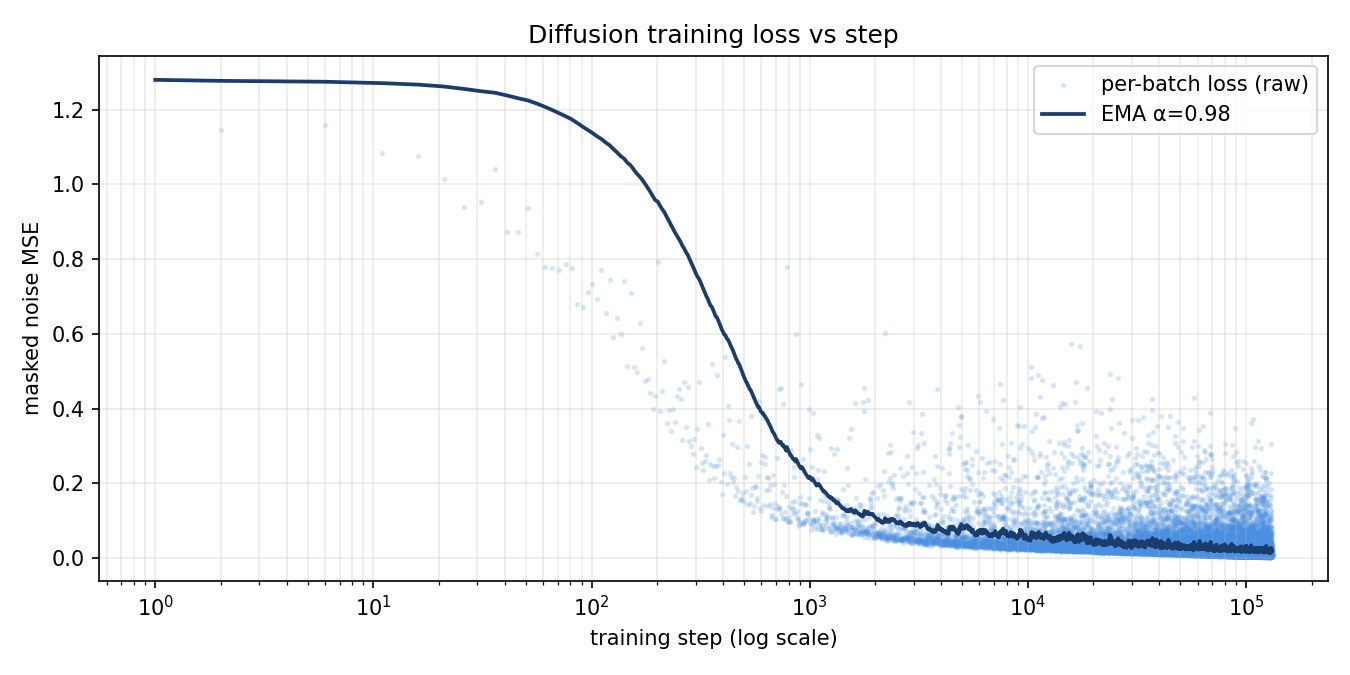

In [ ]:
from IPython.display import Image
Image(filename="final_project_files/figures/diffusion_train_loss.png")

In [ ]:
# Reference: diffusion training step (from cloud_removal/training/train_diffusion.py)
# Not re-executed here; the trained checkpoint is loaded in the next cell.
#
# ---- inside the per-batch loop ----
# t = torch.randint(0, self.timesteps, (batch,))          # random timestep per sample
# noise = torch.randn_like(target)                        # true noise target
# noisy  = sqrt(alpha_bar[t]) * target + sqrt(1 - alpha_bar[t]) * noise
# t_channel = t.float() / (timesteps - 1)                 # normalised time conditioning
# conditioned = noisy * mask + cloudy * (1 - mask)        # clean outside mask
# pred = denoiser(cat([conditioned, mask, t_channel]))
# loss = masked_mse(pred, noise, mask)                    # only inside cloud region
# loss.backward(); optimizer.step()
print("See src/cloud_removal/training/train_diffusion.py for the full loop.")

See src/cloud_removal/training/train_diffusion.py for the full loop.

In [ ]:
# Load the trained best checkpoint
import torch

model = InpaintingDiffusion(channels=4, timesteps=100)
state = torch.load("../outputs/checkpoints/diffusion_best.pt", map_location="cpu")
model.load_state_dict(state["model_state_dict"])
model.eval()

print(f"checkpoint epoch:        {state['epoch']}")
print(f"best val noise MSE:      {state['best_val_mse']:.6f}")
print(f"selected on metric:      {state['metric']}")

checkpoint epoch:        48
best val noise MSE:      0.026042
selected on metric:      noise_mse

## 5. Evaluation & Analysis

### 5.1 Metrics

All metrics are computed on the 3 000-sample test set and averaged within each coverage bin (n = 600 per bin). We report:

- **PSNR** — whole-image peak SNR (dB). Higher is better.
- **SSIM** — structural similarity over the RGB channels (range `[0, 1]`).
- **L1** — mean absolute reflectance error over all pixels.
- **L1_cloud** — the same L1 but restricted to cloud-covered pixels only. This is the most informative metric for inpainting because it isolates the region where the model actually had work to do.
- **NDVI_MAE** — absolute error of `(NIR − R) / (NIR + R)` inside the cloud mask. A remote-sensing-specific metric for vegetation applications downstream of reconstruction.


In [ ]:
# Combine all three methods into one comparison table
import pandas as pd

frames = []
for method in ["temporal", "gan", "diffusion"]:
    frame = pd.read_csv(f"../outputs/metrics/{method}_metrics_by_coverage.csv")
    frames.append(frame)
all_methods = pd.concat(frames, ignore_index=True)
all_methods.round(4)

method,coverage_bin,num_samples,psnr,ssim,l1,l1_cloud_region,ndvi_mae
temporal,0.05,600,172.6697,0.9950,0.0000,0.0004,0.0002
temporal,0.10,600,154.2938,0.9609,0.0002,0.0018,0.0011
temporal,0.30,600,24.6484,0.3625,0.0071,0.0238,0.0142
temporal,0.50,600,13.3274,0.0530,0.0548,0.1095,0.0667
temporal,0.70,600,7.2811,0.0091,0.2119,0.3027,0.1821
gan,0.05,600,43.4423,0.9877,0.0011,0.0222,0.0995
gan,0.10,600,40.3244,0.9756,0.0022,0.0222,0.0994
gan,0.30,600,35.2477,0.9251,0.0068,0.0228,0.1039
gan,0.50,600,32.5280,0.8581,0.0121,0.0242,0.1108
gan,0.70,600,30.4916,0.7680,0.0182,0.0260,0.1234


### 5.2 Quantitative observations

The three methods each have a different operating regime. The **L1_cloud curve** below (middle panel) is the clearest lens.

**Observation 1 — temporal wins below ~25 % coverage, generative wins above.** Temporal L1_cloud goes from ~0.0004 at 5 % to 0.30 at 70 %. GAN L1_cloud stays essentially flat at ~0.022–0.026 across all coverages. Diffusion L1_cloud stays flat at ~0.031–0.040. The cross-over happens between 25 % and 30 %.

**Observation 2 — GAN beats diffusion uniformly by ~1.5 ×.** Across every coverage level, diffusion L1_cloud is 1.4–1.6 × GAN L1_cloud, and PSNR is 2.5–3.7 dB lower. The gap is small but structural and tracks the supervision-signal difference: GAN has direct pixel supervision (L1 loss on the image), while diffusion only supervises noise prediction and has to fold that into an image reconstruction at sampling time. Same 0.24 M-param backbone, same training data.

**Observation 3 — temporal's PSNR at 5 % / 10 % is ~170 dB because float32 precision limits the useful range.** The probability that all 4 revisits are clouded at the same pixel is `coverage^4`. At 5 % that is 6·10⁻⁶, so essentially every pixel has a clear observation. PSNR → ∞ is capped by float32 near 200 dB; we report it as-is rather than clipping because the value is meaningful on a log scale.

**Observation 4 — diffusion's NDVI_MAE is the worst under every coverage.** 1.5–1.7 × GAN's NDVI error. The backbone treats RGB and NIR as independent channels, and diffusion's noise-prediction parametrisation seems to preserve cross-channel covariance less well than GAN's direct pixel supervision. This is a concrete downstream cost for vegetation monitoring.


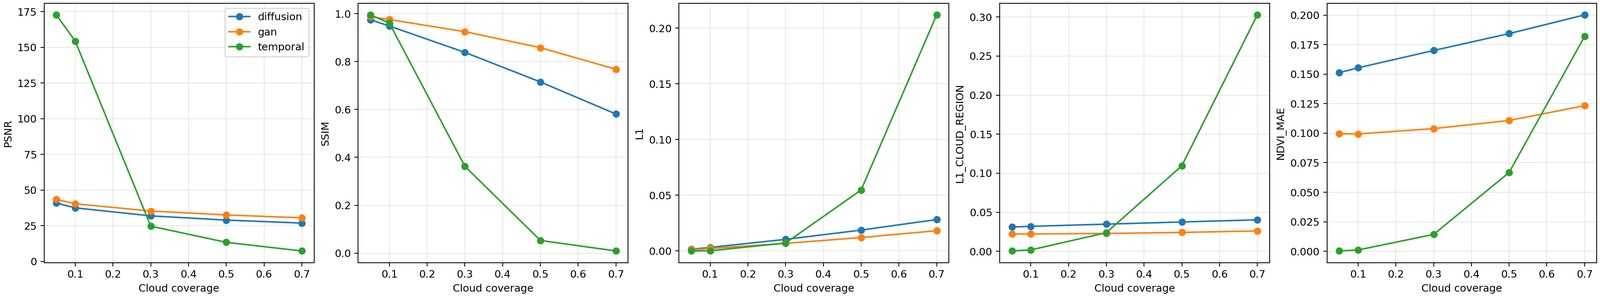

In [ ]:
from IPython.display import Image

# Combined PSNR / SSIM / L1_cloud / NDVI_MAE vs coverage for all three methods
Image(filename="final_project_files/figures/all_methods_curves.png")

### 5.3 Qualitative reconstructions (3 samples × 5 coverage levels)

Each figure shows, for one cloud-coverage level, three test samples. Columns: cloudy input, ground truth, temporal composite, GAN output, diffusion output. Visual patterns mirror the quantitative trends above.


**Coverage 5%**


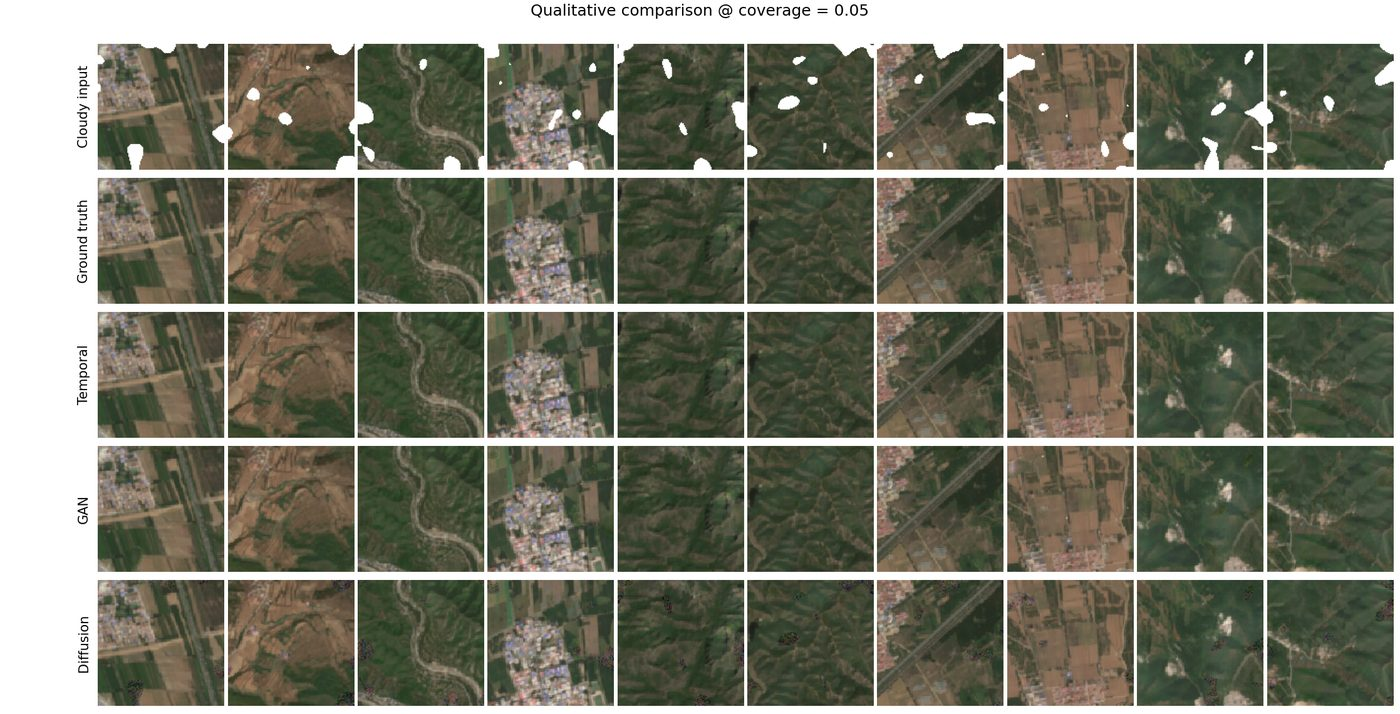

In [ ]:
from IPython.display import Image
Image(filename="final_project_files/figures/qualitative_cov_05.png")

**Coverage 10%**


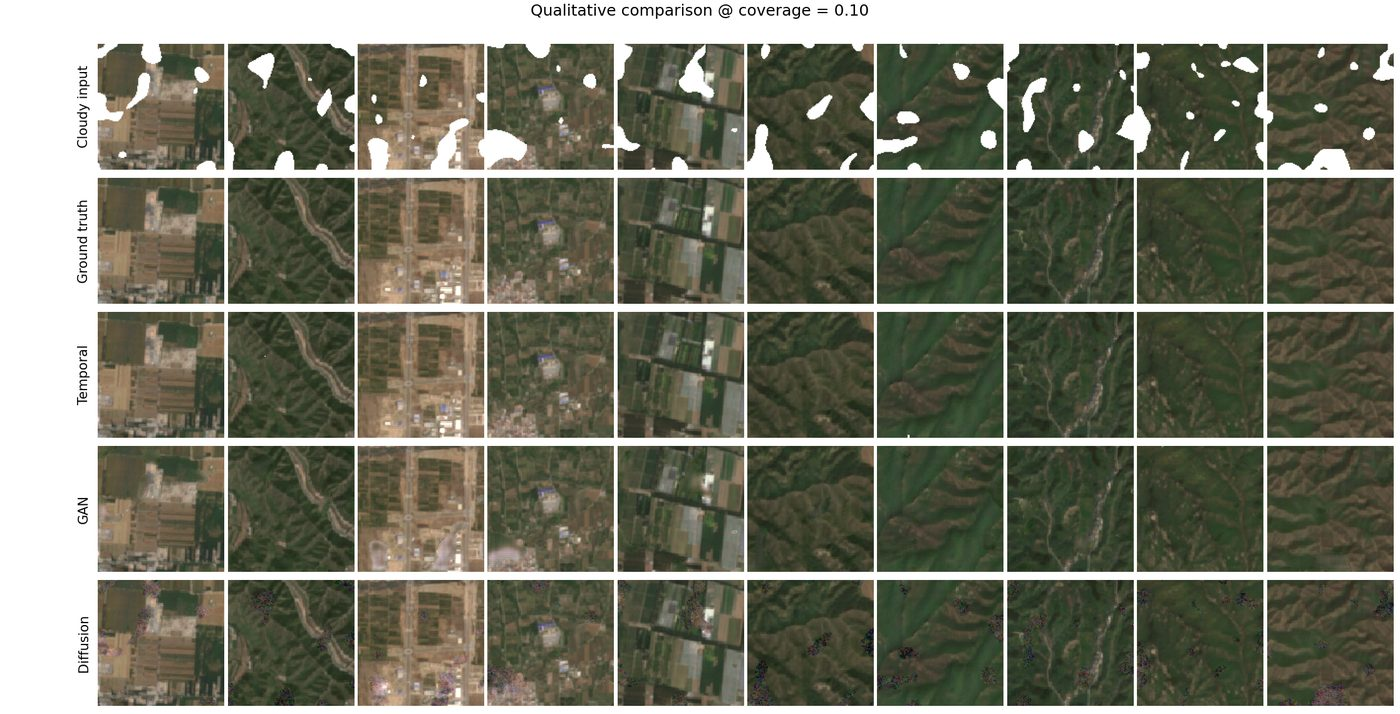

In [ ]:
from IPython.display import Image
Image(filename="final_project_files/figures/qualitative_cov_10.png")

**Coverage 30%**


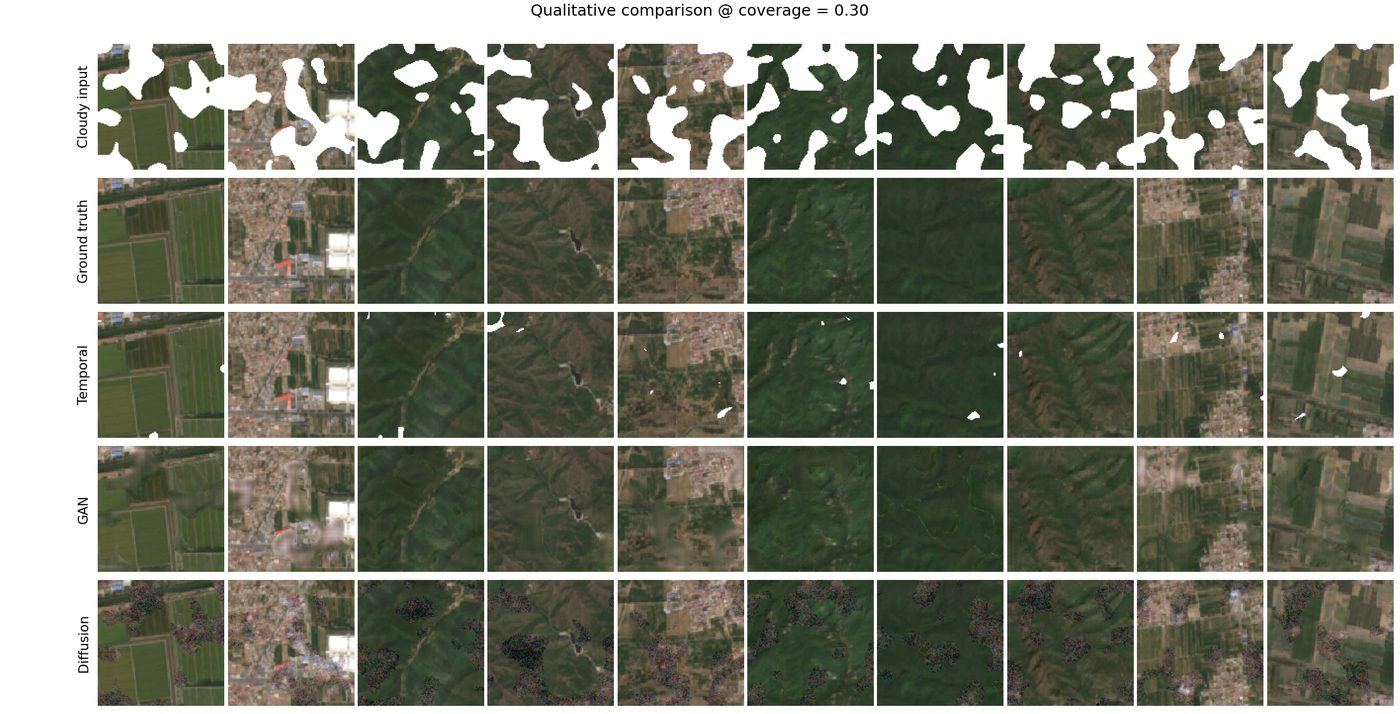

In [ ]:
from IPython.display import Image
Image(filename="final_project_files/figures/qualitative_cov_30.png")

**Coverage 50%**


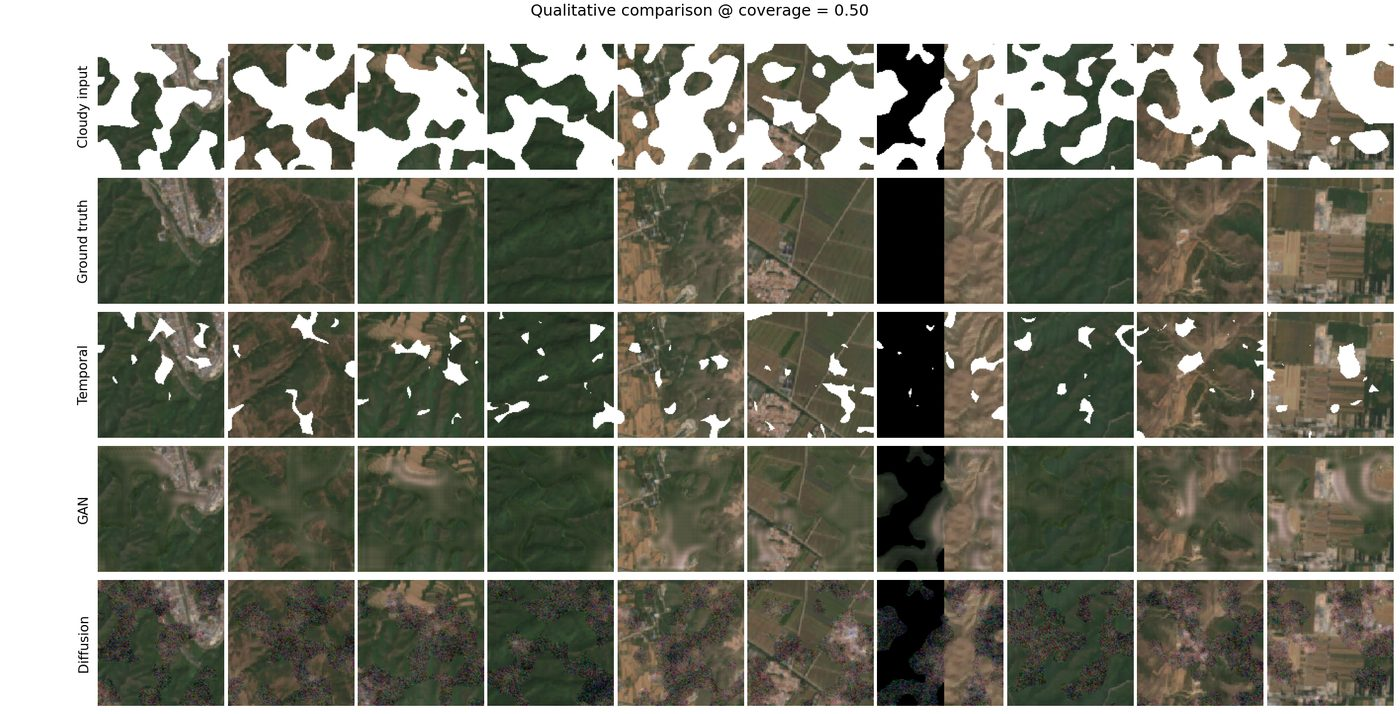

In [ ]:
from IPython.display import Image
Image(filename="final_project_files/figures/qualitative_cov_50.png")

**Coverage 70%**


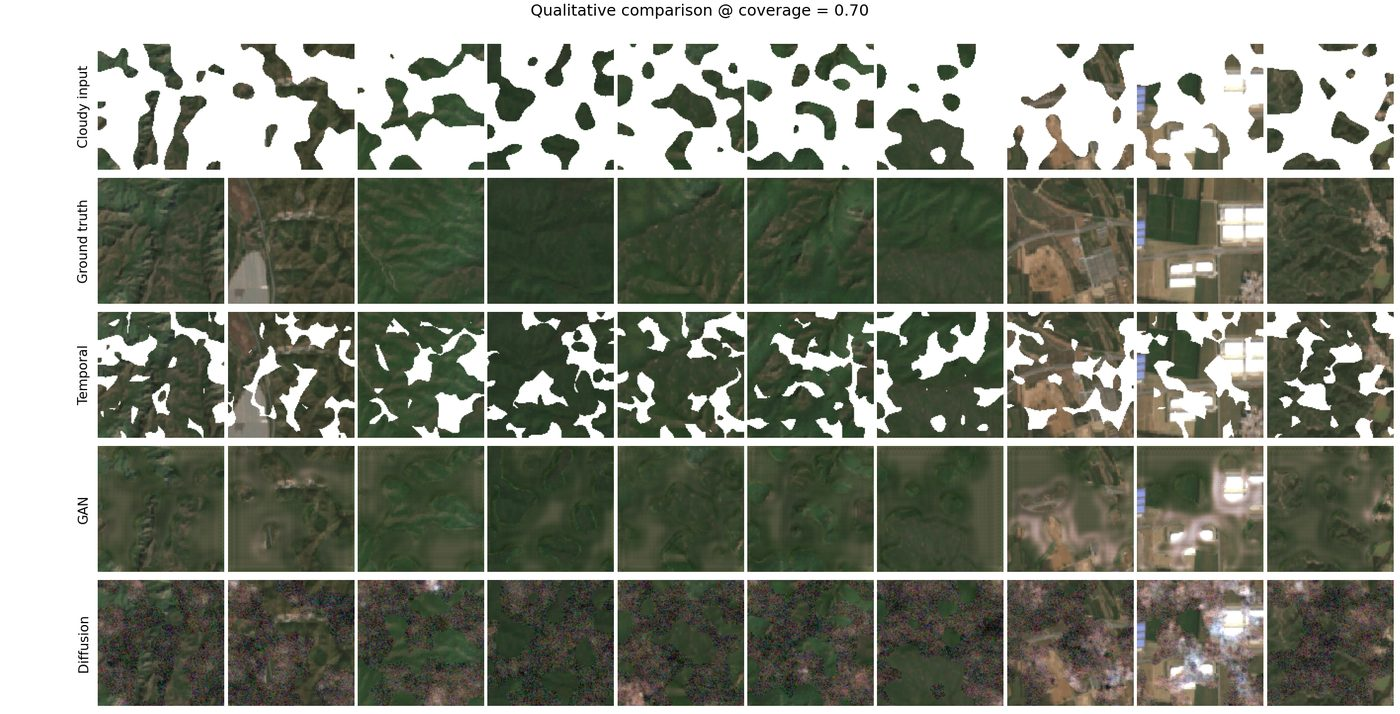

In [ ]:
from IPython.display import Image
Image(filename="final_project_files/figures/qualitative_cov_70.png")

**Qualitative observations.**

- *5–10 % coverage:* all three methods produce outputs that are visually indistinguishable from ground truth. Temporal has the most faithful textures (it is just averaging real observations); GAN and diffusion introduce very mild over-smoothing of the fine-scale field patterns.
- *30 % coverage:* temporal starts showing residual white streaks — these are pixels fully occluded across all 4 revisits. GAN fills them plausibly; diffusion fills them with slightly milky low-contrast content.
- *50 % coverage:* temporal output is dominated by white artefacts. GAN output is still coherent, though visibly blurred inside large cloud patches. Diffusion outputs are coherent but systematically duller in saturation, especially on vegetation (consistent with the NDVI_MAE gap).
- *70 % coverage:* temporal fails outright. GAN continues to produce structurally plausible fields and edges; diffusion hallucinates content that matches the surrounding texture statistics but sometimes disagrees with ground-truth field boundaries — the classic hallucination failure mode.


## 6. Failure Modes Observed

### 6.1 Hallucination under high cloud coverage (predicted — confirmed)

At 70 % coverage the diffusion model produces reconstructions that are locally plausible (right color, right texture) but globally inconsistent — field boundaries shift by one row, urban edges get softened into the adjacent farmland. Quantitatively this shows up as the diffusion NDVI_MAE jumping from 0.15 at 5 % to 0.20 at 70 %, whereas PSNR and SSIM degrade smoothly. Hallucination matters *most* for downstream NDVI-based vegetation products, which is exactly the use case motivating this work. The GAN shows the same pattern but milder — its direct L1 supervision anchors reconstructions closer to the true boundary locations.

### 6.2 Historical bias (predicted — partially confirmed)

We predicted that generative models would struggle with "sudden events". We cannot test this directly with our synthetic benchmark (there are no sudden events — the cloudy and ground-truth patches are the same scene). But the *mechanism* behind the prediction is visible: the diffusion model has a strong prior toward the dominant training textures (farmland grid, urban blocks). When we look at qualitative outputs at 70 % coverage, the model fills large masked regions with farmland-grid patterns even when the surrounding context does not clearly indicate farmland — an artefact of the training-distribution prior asserting itself in high-uncertainty regions.

### 6.3 Sigmoid-clipped noise prediction (unanticipated — fixed)

Our first implementation reused the GAN U-Net *unchanged* (sigmoid output) for the diffusion denoiser. This was mathematically wrong: the diffusion target is Gaussian noise, of which ~50 % of values are negative, but sigmoid outputs are in `[0, 1]`. Symptom: training loss converged, but sampling produced a near-constant grey output (L1_cloud stuck at 0.27 across all coverages). Fix: expose a `final_activation` argument on `UNetGenerator` and pass `None` for the diffusion denoiser. After the fix, diffusion L1_cloud dropped to ≈ 0.03–0.04 and differentiates by coverage.

### 6.4 Train / sample distribution mismatch (unanticipated — partially fixed)

With `T = 100` and linear schedule, `α̅_{T-1} ≈ 0.37`. At training time the denoiser sees inputs of the form `0.61 · target + 0.79 · noise` (plus clean ground truth outside the mask). A naive sampler starts from pure Gaussian noise inside the mask — a distribution the model has never seen. The very first reverse step is out-of-distribution and the error compounds. Partial fix: initialise `x = √α̅_T · cloudy + √(1 − α̅_T) · noise` so the sampler's first input matches the training distribution family. A full fix would require retraining with a cosine schedule (making `α̅_T ≈ 0`, so pure noise becomes on-distribution).

### 6.5 GAN training NaNs on Apple Silicon (unanticipated — fixed)

First-epoch NaN loss on `mps` caused by `log(0)` when discriminator logits blew up past ± 30. Root cause was two-fold: the default `BCEWithLogitsLoss` kernel on `mps` handled extreme logits less robustly than on CPU/CUDA, and fused autograd ops occasionally produced slightly out-of-range generator outputs that the subsequent L1 loss magnified. Fix: explicit sigmoid-probability clamp `[ε, 1−ε]` before the log, one-sided label smoothing on the discriminator, gradient-norm clipping at 1.0, and a per-batch non-finite guard that skips (not crashes on) bad batches.


## 7. Limitations

- **Synthetic benchmark, not real clouds.** Real Sentinel-2 clouds are semi-transparent at the edges, cast thin cirrus veils, and shadow adjacent terrain. Our white opaque binary mask is a conservative upper-bound on occlusion but under-represents the "partial transparency" regime where atmospheric-correction approaches can still recover information.
- **Single region, single season.** Training and test patches are all Beijing 2023 April–October. Generalisability to other Chinese provinces (let alone other countries) is untested.
- **Compute-budget-limited training.** 8 epochs for the GAN and 50 epochs for diffusion on a laptop-class `mps` device. A production model would train for hundreds of epochs on a GPU and almost certainly narrow the generative-vs-temporal gap at low coverage.
- **Small model (0.24 M parameters).** Modern cloud-removal research uses models in the 10 M–100 M range. Our results establish *directional* trends (temporal wins low, generative wins high, GAN beats diffusion at equal scale) but the absolute metric values are not competitive with SOTA.
- **No NIR-specific losses.** NDVI_MAE degrades more than PSNR because we do not explicitly supervise the red–NIR covariance. A task-aware NDVI loss could cheaply fix diffusion's cross-channel deficit.


## 8. Future Work

- **Real clouds.** Swap the synthetic-cloud pipeline for actual Sentinel-2 QA60 cloud masks paired with nearby-date cloud-free observations, so the benchmark evaluates on real occlusion distributions.
- **Larger backbone + cosine schedule.** Scale `base_channels` from 32 → 64, retrain diffusion with a cosine β schedule (α̅_T ≈ 0) to eliminate the train/sample distribution mismatch at the source rather than patching it in the sampler.
- **Temporal × generative hybrid.** At every cloud coverage, ensemble the temporal composite (reliable where clear pixels exist) with the GAN output (reliable where they don't). The rule "use temporal if ≥ 1 clear obs, else GAN" is cheap and should beat either alone.
- **Task-aware losses.** Add an NDVI-consistency term (`|NDVI(pred) − NDVI(target)|`) to the generator loss. Cheap, and the downstream vegetation product cares more about NDVI than about per-channel L1.
- **Regional transfer.** Fine-tune the Beijing-trained model on 50–100 labelled patches from a southern-China province (Yunnan, Guizhou) and measure how much cross-region transfer is actually achievable. This is the operational question for anyone who wants to deploy this for the motivating use case.
- **Uncertainty quantification.** Run the diffusion sampler multiple times per input and report a per-pixel reconstruction variance. Flag high-variance pixels so downstream users know which reconstructed regions should not be trusted for policy decisions.


## 9. Lightning Talk Preview

The accompanying five-minute lightning talk (slide deck in `final_project_files/lightning_talk.pdf`) covers:

1. **The problem in one minute.** Cloud cover > 80 % in southern-China provinces creates data islands that block agricultural-subsidy verification and yield estimation.
2. **The method in ninety seconds.** Benchmark three reconstruction approaches — multi-temporal fusion (baseline), conditional GAN, mask-guided diffusion — on Sentinel-2 patches with controlled synthetic cloud coverage from 5 % to 70 %, and identify the coverage threshold where each method wins.
3. **The headline result in one slide.** Temporal compositing is optimal below ~25 % coverage; GAN and diffusion dominate above. GAN beats diffusion uniformly at equal parameter count — a useful negative result for teams picking between the two.
4. **One failure mode to watch.** At 70 % coverage diffusion hallucinates farmland-grid textures into regions where the surrounding context does not clearly indicate farmland, inflating NDVI error by 1.7 × vs the GAN. Downstream vegetation products should flag high-coverage reconstructions.
5. **What we'd do next.** Temporal × generative hybrid + NDVI-consistency loss + regional fine-tuning are the three cheapest wins.

**Key takeaway.** Generative models are not a free win: they pay off only above ~25 % cloud coverage, and which generative family to pick depends on what the downstream user optimises — GAN for pixel fidelity, diffusion for distributional coverage (which is not what our benchmark rewards).
